In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
project_root = Path("..").resolve()

In [3]:


# ── Configuration: header rows ──────────────────────────────────────────────
HEADER_ROW_GALLIKER = 0
HEADER_ROW_SPOT     = 0

# ── Data: Load profiles (Galliker) ──────────────────────────────────────────
galliker_path = project_root / "data" / "01_raw" / "260707_Lastgänge_galliker.xlsx"
df_galliker = pd.read_excel(galliker_path, header=HEADER_ROW_GALLIKER)
df_galliker = df_galliker.drop(index=0)

# ── Price Data (Swiss day-ahead spot) ───────────────────────────────────────
spot_ch_path = project_root / "data" / "01_raw" / "spot_ch_25.xlsx"
df_spot = pd.read_excel(spot_ch_path, header=HEADER_ROW_SPOT)



# ── Time Index ───────────────────────────────────────────────────────────────
# Built from the actual length of the load-profile data (15-min resolution).
start_time = pd.Timestamp('2025-01-01', tz='Europe/Zurich')
idx = pd.date_range(
    start=start_time,
    freq='15min',
    periods=len(df_galliker),
    tz='Europe/Zurich',
)

df_galliker.index = idx
df_galliker = df_galliker.drop(columns='Unnamed: 0')
df_galliker = df_galliker.astype(float)
df_galliker = df_galliker * 4 / 1000 # from kWh to MW

spot_column = 'Spot CH [Euro/MWh]'
df_spot = df_spot.iloc[:len(df_galliker)]
df_spot.index = idx
spot_price_series = df_spot['Spot CH [Euro/MWh]']

df_galliker['Total_San_Antonino'] = df_galliker['Bezug San Antonino'] - df_galliker['Überschuss San Antonino']
df_galliker['Total_Schachen'] = df_galliker['Bezug Schachen'] - df_galliker['Überschuss Schachen']

p_max_antinino = df_galliker['Bezug San Antonino'].max()
p_max_schachen = df_galliker['Bezug Schachen'].max()

# Run Simulation
## Run entire time horizon at once

In [4]:
# import pyomo.environ as pyo
# from hems_resopt.components.grid import GridPeakShave
# from res_opt_core import EnergyModel, Battery, AuctionMarket, plot_battery_operation, Grid, Load, Pv
# from res_opt_core.core.components.energy_balance import GridLimits
# from res_opt_core.valuator.components.grid import GridLimitsWithFees
# from hems_resopt.components.ev import EV
# from pyomo.contrib.solver.solvers.highs import Highs

# # Change the solver attributes so that solving doesnt take too long
# custom_solver = Highs()
# # custom_solver.config.time_limit = 300.0
# custom_solver.config.rel_gap = 0.05          # the gap allowed to the optimal solution
# # custom_solver.config.solver_options = {
# #     "presolve": "on",
# #     "mip_heuristic_effort": 0.2,
# #     "output_flag": True,     # ensure HiGHS actually prints its log
# #     "log_to_console": True,  # some HiGHS builds use this name instead/additionally
# # }

# # ── Simulation Configuration ───────────────────────────────────────────────────
# p_max_Netz = p_max_antinino
# kosten_lastspitze = 7190        # CHF/MW
# arbeitspreis_netz_bezug = 42.4    # CHF/MWh
# arbeitspreis_netz_einspeisung = 0

# Anschlussleistung_SanAntonino = 1.6  # MW
# cos_phi = 0.86
# Anschlussleistung_Schachen = 0.935 * cos_phi  # MW

# output_dir = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed'

# # ── Model ─────────────────────────────────────────────────────────────────────
# model = EnergyModel(
#     num_steps=len(df_galliker.index),
#     slot_length="15min",
#     solver=custom_solver,
#     timestamp=df_galliker.index,
# )


# # ── Load ───────────────────────────────
# Building = Load(
#     name='San_Antonino',
#     load_curve=df_galliker['Bezug San Antonino'],
#     lost_load_allowed=False, # Kann Load ignoriert werden -> nicht Erfüllung der Menge die bezogen werden sollte
#     value_of_lost_load=1000.0
# )
# model.add_component(Building)

# # ── PV ───────────────────────────────
# pv = Pv(
#     name='PV_San_Antonino',
#     power_max=df_galliker['Überschuss San Antonino'],
#     power_min=0,
#     # allow_spill=True, # Man kann curtailen (last kappen)
#     # cost_spill=2 # curtailment price
# )
# model.add_component(pv)

# # ── BESS ───────────────────────────────
# bess = Battery(
#     name='bess_san_antonino',
#     power_nominal=5,
#     energy_capacity=15,
#     eta=0.85 # efficiency
# )
# model.add_component(bess)

# # ── Market ──────────────────────────────────────────────────────────────────
# spot_ch = AuctionMarket(
#     name='spot_ch',
#     price_curve=spot_price_series,
#     market_time_unit='hour' # definiert die Auflösung des Marktes = muss produkt für 1h kaufen
# )
# model.add_component(spot_ch)

# # ── Grid  ─────────────────────
# grid = GridPeakShave(
#     name='Grid_with_peakshave',
#     assets=[bess, pv, Building],
#     markets=[spot_ch],
#     peak_power_price=kosten_lastspitze,
#     time_horizon_peak='month_daylight_saving',
#     power_max=Anschlussleistung_SanAntonino,
#     power_min=-Anschlussleistung_SanAntonino,
#     fee_export=arbeitspreis_netz_einspeisung,
#     fee_import=arbeitspreis_netz_bezug,
# )
# model.add_component(grid)

# # grid = GridLimitsWithFees(
# #     inbound_components=[],
# #     name = 'Grid_with_Limits',
# #     power_max = Anschlussleistung_SanAntonino,
# #     power_min = -Anschlussleistung_SanAntonino,
# #     fee_export=0,
# #     fee_import=100,
# # )
# # model.add_component(grid)

# # ── Run ───────────────────────────────────────────────────────────────────────
# model.build_and_run(silent=False)  # solver output visible

# df_results = model.results.timeseries_to_pandas()
# df_results.to_csv(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\galliker_san_antonino.csv')

## Run every Month individually


In [5]:
import pyomo.environ as pyo
from hems_resopt.components.grid import GridPeakShave
from res_opt_core.core import EnergyModel, Battery, AuctionMarket, plot_battery_operation, Grid, Load, Pv
from res_opt_core.core.components.energy_balance import GridLimits
from res_opt_core.valuations.components.grid import GridLimitsWithFees
from hems_resopt.components.ev import EV
from pyomo.contrib.solver.solvers.highs import Highs
import os

# Change the solver attributes so that solving doesnt take too long
custom_solver = Highs()
# custom_solver.config.time_limit = 330.0 #Currently no time limit gap and only gap to optimal solution as finishing line
custom_solver.config.rel_gap = 0.065          # the gap allowed to the optimal solution
custom_solver.config.solver_options = {
    "presolve": "on",
    "mip_heuristic_effort": 0.2,
}

# ── Simulation Configuration ───────────────────────────────────────────────────
p_max_Netz = p_max_antinino
kosten_lastspitze = 7190        # CHF/MW
arbeitspreis_netz_bezug = 42.4    # CHF/MWh
arbeitspreis_netz_einspeisung = None

Anschlussleistung_SanAntonino = 1.6  # MW
cos_phi = 0.86
Anschlussleistung_Schachen = 0.935 * cos_phi  # MW

output_dir = project_root / "data" / "03_processed"

## Run 2025
df_galliker = df_galliker.loc['2026']
spot_price_series = spot_price_series.loc['2026']

# ── Build monthly input dictionaries ────────────────────────────────────────────
months = df_galliker.index.to_series().dt.to_period('M').unique()
months = sorted(months)

galliker_by_month = {}
spot_by_month = {}

for month in months:
    month_mask = df_galliker.index.to_period('M') == month
    galliker_by_month[month] = df_galliker.loc[month_mask].copy()
    spot_by_month[month] = spot_price_series.loc[month_mask].copy()

print(f"ℹ️  Split data into {len(months)} monthly chunks: {[str(m) for m in months]}")

# ── Run the simulation once per month ──────────────────────────────────────────
results_per_month = {}

for month in months:
    csv_path = os.path.join(output_dir, f'galliker_schachen_{month}.csv')

    if os.path.exists(csv_path):
        print(f"⏭️  Skipping month {month} — CSV already exists at {csv_path}")
        continue

    print(f"\n{'='*60}")
    print(f"  Running simulation for month: {month}")
    print(f"{'='*60}")

    try:
        df_galliker_m = galliker_by_month[month]
        spot_m = spot_by_month[month]
        idx_m = df_galliker_m.index


        # ── Model ─────────────────────────────────────────────────────────────
        model = EnergyModel(
            num_steps=len(idx_m),
            slot_length="15min",
            solver=custom_solver,
            timestamp=idx_m,
        )

        # ── Load ──────────────────────────────────────────────────────────────
        Building = Load(
            name='Schachen',
            load_curve=df_galliker_m['Bezug Schachen'],
            lost_load_allowed=False,
            # value_of_lost_load=1000.0,
        )
        model.add_component(Building)

        # ── PV ────────────────────────────────────────────────────────────────
        pv = Pv(
            name='PV_Schachen',
            power_max=df_galliker_m['Überschuss Schachen'],
            # power_min=0,
            allow_spill=False,
            # cost_spill=2,
        )
        model.add_component(pv)

        # ── BESS ──────────────────────────────────────────────────────────────
        bess = Battery(
            name='bess_schachen',
            power_nominal=5,
            energy_capacity=15,
            eta=0.85,
            soc_initial=0.5,
            soc_final=0.5
        )
        model.add_component(bess)

        # ── Market ────────────────────────────────────────────────────────────
        spot_ch = AuctionMarket(
            name='spot_ch',
            price_curve=spot_m,
            market_time_unit='hour',
        )
        model.add_component(spot_ch)

        # ── Grid ──────────────────────────────────────────────────────────────
        # Behind-the-meter Case
        grid = GridPeakShave(
            name='Grid_with_peakshave',
            assets=[bess, pv, Building],
            markets=[spot_ch],
            peak_power_price=kosten_lastspitze,
            time_horizon_peak='month_daylight_saving',
            power_max=Anschlussleistung_Schachen,
            power_min=-Anschlussleistung_Schachen,
            fee_export=arbeitspreis_netz_einspeisung,
            fee_import=arbeitspreis_netz_bezug,
        )

        # In Front-of-the-meter Case -> no grid fees
        # grid = Grid(
        #     name='Grid-no-grid-fees',
        #     assets=[bess, pv, Building ],      # -> we can only look at BESS since PV and building still has fees
        #     markets=[spot_ch],
        #     power_max=Anschlussleistung_Schachen,
        #     power_min=-Anschlussleistung_Schachen,
        # )
        model.add_component(grid)

        # ── Run ───────────────────────────────────────────────────────────────
        model.build_and_run(silent=False)

        df_results_m = model.results.timeseries_to_pandas()

        results_per_month[month] = {
            'df_results': df_results_m,
            'df_galliker': df_galliker_m,
            'spot_price': spot_m,
        }

        print(f"✅ Month {month} solved. df_results shape: {df_results_m.shape}")
        df_results_m.to_csv(csv_path)
        # print(f"💾 Saved: {csv_path}")

    except Exception as e:
        print(f"⛔ Month {month} FAILED — {type(e).__name__}: {e}")
        results_per_month[month] = {'error': str(e)}
        continue

print("\nAll months processed.")

# ── Final status summary ───────────────────────────────────────────────────────
for month, res in results_per_month.items():
    status = '⛔ FAILED' if 'error' in res else '✅ OK'
    print(f"  {month}: {status}")


/var/folders/r4/7hjg9vf1437295_tqckykhcc0000gn/T/ipykernel_48078/931574270.py:36: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = df_galliker.index.to_series().dt.to_period('M').unique()
/var/folders/r4/7hjg9vf1437295_tqckykhcc0000gn/T/ipykernel_48078/931574270.py:43: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month_mask = df_galliker.index.to_period('M') == month


ℹ️  Split data into 7 monthly chunks: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']

  Running simulation for month: 2026-01
✅ Month 2026-01 solved. df_results shape: (2976, 34)

  Running simulation for month: 2026-02
✅ Month 2026-02 solved. df_results shape: (2688, 34)

  Running simulation for month: 2026-03
✅ Month 2026-03 solved. df_results shape: (2972, 34)

  Running simulation for month: 2026-04
✅ Month 2026-04 solved. df_results shape: (2880, 34)

  Running simulation for month: 2026-05
✅ Month 2026-05 solved. df_results shape: (2976, 34)

  Running simulation for month: 2026-06
✅ Month 2026-06 solved. df_results shape: (2880, 34)

  Running simulation for month: 2026-07
✅ Month 2026-07 solved. df_results shape: (4, 34)

All months processed.
  2026-01: ✅ OK
  2026-02: ✅ OK
  2026-03: ✅ OK
  2026-04: ✅ OK
  2026-05: ✅ OK
  2026-06: ✅ OK
  2026-07: ✅ OK


In [6]:
# # ── Rebuild results_per_month from saved CSVs, then concatenate ───────────────
# import glob

# csv_files = sorted(glob.glob(os.path.join(output_dir, 'galliker_schachen_*.csv')))

# # Exclude the combined yearly file itself, in case it already exists in the folder
# csv_files = [f for f in csv_files if 'galliker_schachen_2026.csv' not in os.path.basename(f)]

# print(f"ℹ️  Found {len(csv_files)} monthly CSV files to combine.")

# monthly_dfs = {}
# for csv_file in csv_files:
#     filename = os.path.basename(csv_file)
#     month_label = filename.replace('galliker_schachen_', '').replace('.csv', '')

#     df_month = pd.read_csv(csv_file, index_col=0)
#     # Explicitly convert to datetime, coercing any unparseable values to NaT
#     # so we can detect and inspect them rather than silently mixing types.
#     df_month.index = pd.to_datetime(df_month.index, errors='coerce', utc=True)

#     bad_rows = df_month.index.isna().sum()
#     if bad_rows > 0:
#         print(f"⚠️  {month_label}: {bad_rows} rows had an unparseable index — dropping them.")
#         df_month = df_month[df_month.index.notna()]

#     monthly_dfs[month_label] = df_month
#     print(f"  Loaded {month_label}: shape {df_month.shape}, index dtype: {df_month.index.dtype}")

# if monthly_dfs:
#     df_results_all_months = pd.concat(monthly_dfs.values(), axis=0).sort_index()
#     print(f"\n📊 Combined df_results shape across all months: {df_results_all_months.shape}")

#     combined_path = os.path.join(output_dir, 'galliker_schachen_2026.csv')
#     df_results_all_months.to_csv(combined_path)
#     print(f"💾 Saved combined file: {combined_path}")
# else:
#     print("⚠️  No monthly CSVs found — nothing to combine.")


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


def plot_results(
    df: pd.DataFrame,
    columns: list[str],
    title: str = "Model Results",
    ylabel: str = "Power [kW]",
    figsize: tuple = (14, 5),
    timestamp_col: str = "timestamp",
) -> None:
    """Plots selected columns from a results DataFrame as time series lines.

    Args:
        df: Results DataFrame, typically from model.results.timeseries_to_pandas().
        columns: List of column names to plot.
        title: Title of the plot.
        ylabel: Label for the y-axis.
        figsize: Figure size as (width, height).
        timestamp_col: Name of the timestamp column to use as x-axis.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # use timestamp as x-axis if available, otherwise fall back to integer index
    x = df[timestamp_col] if timestamp_col in df.columns else df.index

    for col in columns:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found in DataFrame — skipping.")
            continue
        ax.plot(x, df[col], label=col, linewidth=1.0)

    # format x-axis as dates if timestamps are available
    if timestamp_col in df.columns:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        fig.autofmt_xdate()

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


def get_month_results(results_per_month: dict, month) -> pd.DataFrame:
    """Pulls one month's results out of the results_per_month dict and enriches it.

    Args:
        results_per_month: Dict produced by the monthly simulation loop, keyed by
            pd.Period (e.g. Period('2026-03', 'M')), with values containing
            'df_results' and 'spot_price'.
        month: The month key to extract. Accepts either a pd.Period matching the
            dict's keys, or a string like "2026-03" that will be converted.

    Returns:
        The enriched results DataFrame for that month (timestamp as index,
        Spot_price and load_at_meter columns added).

    Raises:
        KeyError: If the requested month is not present in results_per_month,
            or if that month's entry only contains an 'error' (failed run).
    """
    # Allow passing a plain string like "2026-03" instead of a pd.Period.
    if not isinstance(month, pd.Period):
        month = pd.Period(month, freq="M")

    if month not in results_per_month:
        raise KeyError(f"Month {month} not found. Available months: {sorted(results_per_month.keys())}")

    entry = results_per_month[month]
    if "error" in entry:
        raise KeyError(f"Month {month} failed during simulation: {entry['error']}")

    # Copy so repeated calls / re-plots don't mutate the cached dict entry.
    df_results_m = entry["df_results"].copy()
    spot_m = entry["spot_price"]

    # Ensure the index is a tz-aware DatetimeIndex in Europe/Zurich.
    if not isinstance(df_results_m.index, pd.DatetimeIndex):
        df_results_m.index = pd.to_datetime(df_results_m.index)
    if df_results_m.index.tz is None:
        df_results_m.index = df_results_m.index.tz_localize("Europe/Zurich")
    else:
        df_results_m.index = df_results_m.index.tz_convert("Europe/Zurich")

    # Attach the spot price (scaled for visual comparison) — aligns by index.
    df_results_m["Spot_price"] = spot_m / 100


    return df_results_m


In [8]:
df_results_m.columns.to_list()

['Schachen__var_power',
 'Schachen__var_power_reserve_up',
 'Schachen__var_power_reserve_down',
 'Schachen__var_lost_load',
 'PV_Schachen__var_power',
 'PV_Schachen__var_power_reserve_up',
 'PV_Schachen__var_power_reserve_down',
 'PV_Schachen__var_spill',
 'bess_schachen__var_power',
 'bess_schachen__var_power_reserve_up',
 'bess_schachen__var_power_reserve_down',
 'bess_schachen__var_soc_slot_start',
 'bess_schachen__var_soc_slot_end',
 'bess_schachen__var_min_energy_violation',
 'bess_schachen__var_max_energy_violation',
 'bess_schachen__var_power_charge',
 'bess_schachen__var_power_discharge',
 'bess_schachen__var_is_charging',
 'bess_schachen__var_is_discharging',
 'bess_schachen__var_power_max_violation',
 'bess_schachen__var_power_min_violation',
 'bess_schachen__var_energy_reserve_up_slot_start',
 'bess_schachen__var_energy_reserve_down_slot_start',
 'bess_schachen__var_energy_reserve_up_slot_end',
 'bess_schachen__var_energy_reserve_down_slot_end',
 'bess_schachen__var_soc_min_

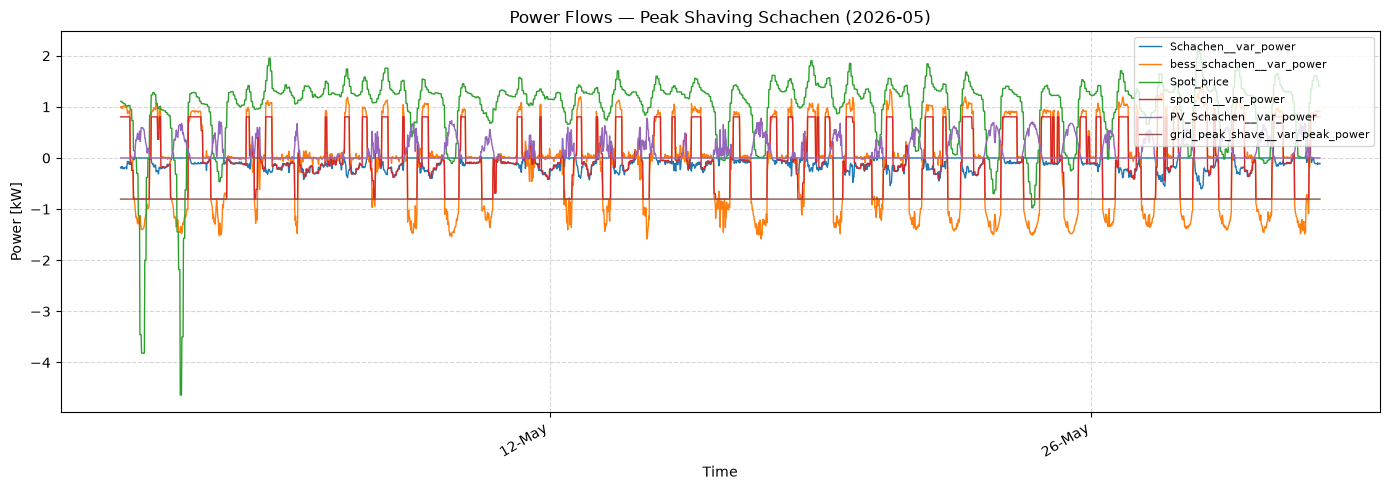

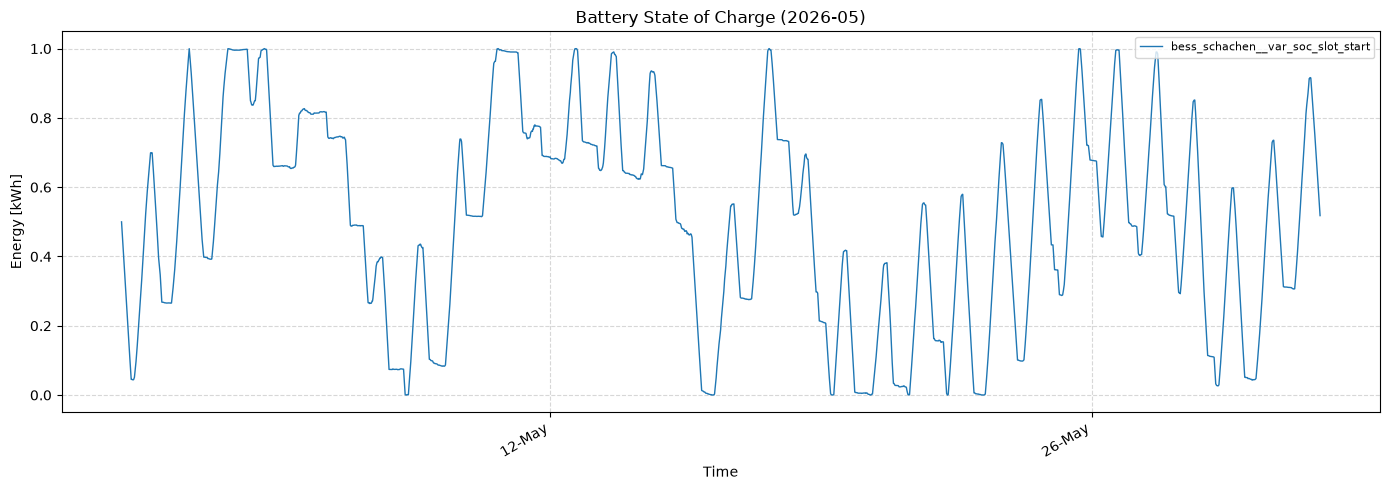

In [9]:

# ── Pick the month to inspect ───────────────────────────────────────────────
month_to_plot = "2026-05"  # change this to any month present in results_per_month
df_results_m = get_month_results(results_per_month, month_to_plot)

# plot power flows
plot_results(
    df=df_results_m,
    columns=[
        "Schachen__var_power",
        "bess_schachen__var_power",
        "Spot_price",
        "spot_ch__var_power",
        "PV_Schachen__var_power",
        "grid_peak_shave__var_peak_power"
    ],
    title=f"Power Flows — Peak Shaving Schachen ({month_to_plot})",
    ylabel="Power [kW]",
)

# plot battery SoC separately
plot_results(
    df=df_results_m,
    columns=["bess_schachen__var_soc_slot_start"],
    title=f"Battery State of Charge ({month_to_plot})",
    ylabel="Energy [kWh]",
)